# CO Climate Assessment - Climate Data Colorbars

This notebook presents colormaps for use with climate hazard data provided by the Univ of WY and CSU teams. These are based on modified versions of the [color tables originally provided by the Governor's Office](https://docs.google.com/spreadsheets/d/e/2PACX-1vSQijfRv8tJvi3Rtei84MhcuK-IaqCNzwfSWco56Ez_MAX04-zRK3r6HaQYFnOxqA/pubhtml?gid=1048139529&single=true) where applicable, otherwise falling back on the CVD-friendly geoscience colormaps of `cmocean` or standard tables in `matplotlib`.

### In This Notebook

- <a href="demo">Initial Overview</a>
- <a href="by-hazard">Listing by Hazard</a>
- <a href="cvd-analysis">CVD Testing for modified `govoffice` tables</a>

---

<a id="demo"></a>

## Initial Overview

In [1]:
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray
import requests
import fsspec

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from matplotlib.figure import Figure
from metpy.plots import USCOUNTIES, USSTATES
import skimage.color as skcolor
from colorspacious import cspace_convert
import cmocean

In [2]:
#####################################
# Copy this code block to use these #
# colormaps in your own scripts!    #
# (with corresponding imports)      #
#####################################

# Fetch the custom colormaps
colormap_url = (
    "https://raw.githubusercontent.com/jthielen/co_climate_hazard_maps/refs/heads/main/"
    "custom_colormaps.json"
)
try:
    r = requests.get(colormap_url)
    r.raise_for_status()
    color_data = r.json()
except Exception as e:
    print(f"Could not access colormap reference - {e}")

# Register them with matplotlib
for var_name, this_var in color_data['colormaps'].items():
    lutsize = mpl.rcParams['image.lut'] if this_var["quantization_levels"] == "LUT" else this_var["quantization_levels"]
    cmap = colors.LinearSegmentedColormap.from_list(var_name, this_var["color_list"], lutsize)
    cmap_reversed = colors.LinearSegmentedColormap.from_list(var_name + "_r", this_var["color_list"][::-1], lutsize)
    mpl.colormaps.register(name=var_name, cmap=cmap, force=True)
    mpl.colormaps.register(name=var_name + "_r", cmap=cmap_reversed, force=True)

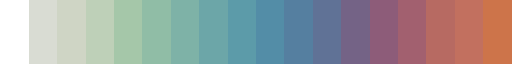

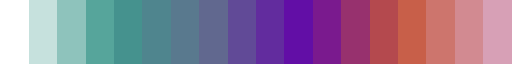

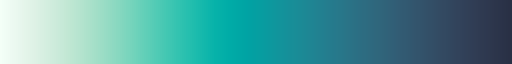

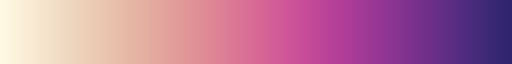

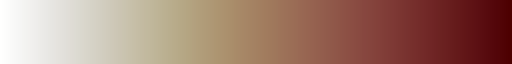

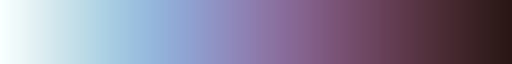

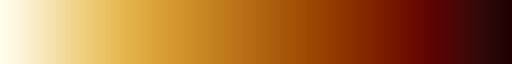

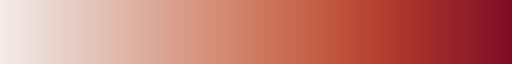

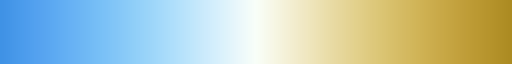

In [3]:
# Display all the custom colormaps
for cmap_name in color_data['colormaps']:
    if 'improved_equivalent' not in color_data['colormaps'][cmap_name]:
        display(plt.get_cmap(cmap_name))

<a id="by-hazard"></a>

## Listing by Hazard

In [4]:
symbology_specs_url = (
    "https://raw.githubusercontent.com/jthielen/co_climate_hazard_maps/refs/heads/main/"
    "symbology_specifications.tsv"
)
try:
    symbology_table = pd.read_csv(symbology_specs_url, sep="\t")
except Exception as e:
    print(f"Could not access hazard symbology reference - {e}")

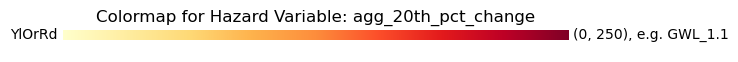

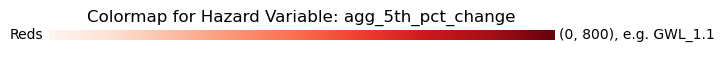

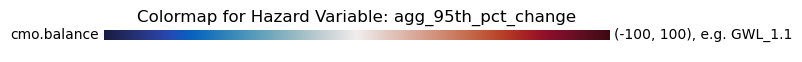

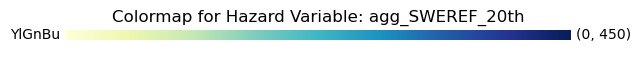

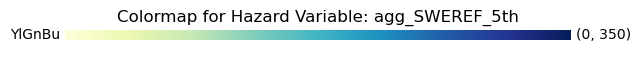

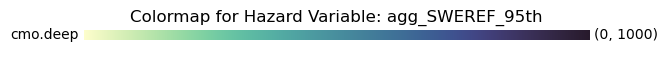

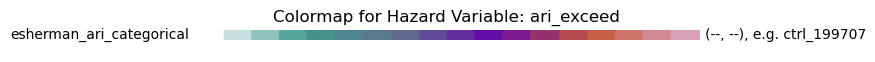

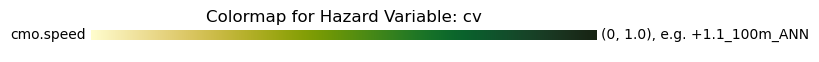

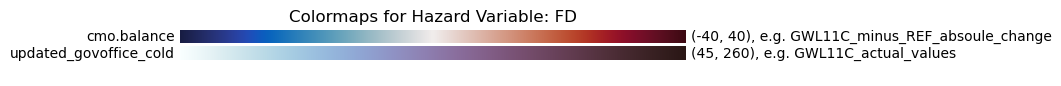

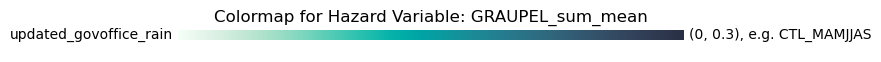

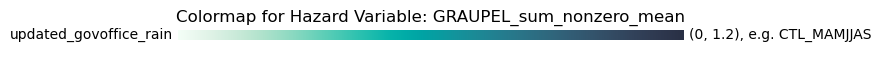

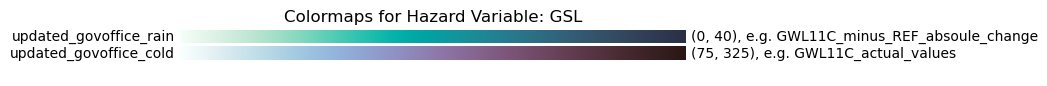

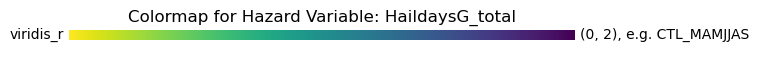

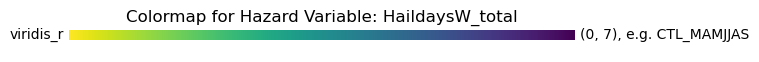

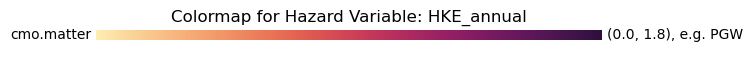

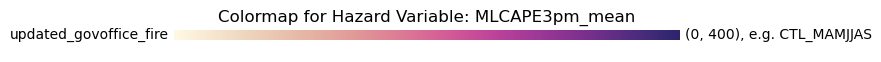

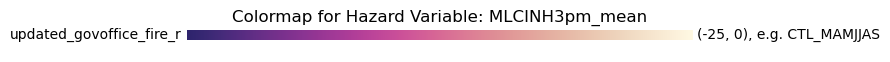

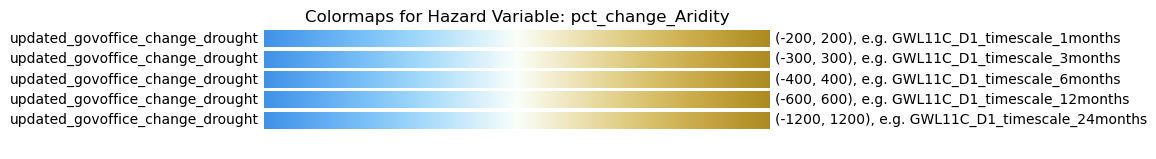

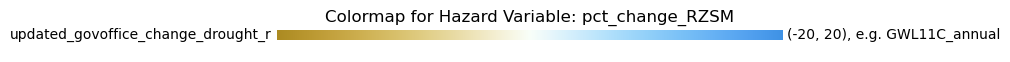

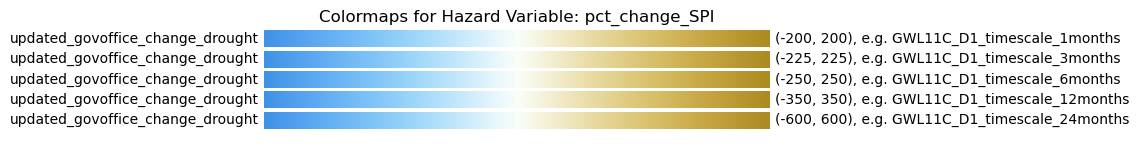

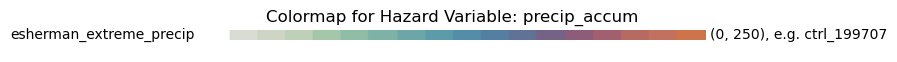

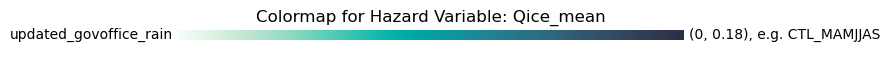

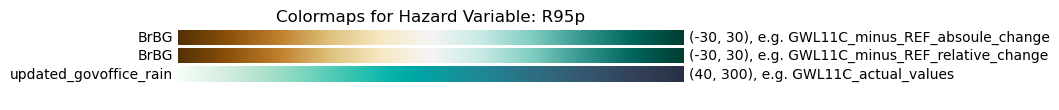

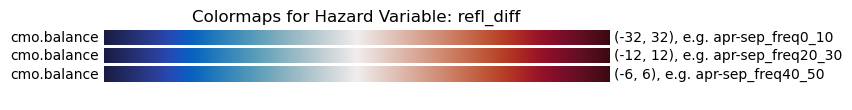

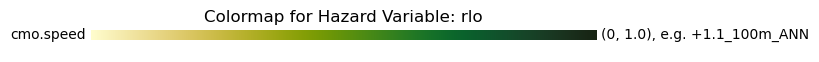

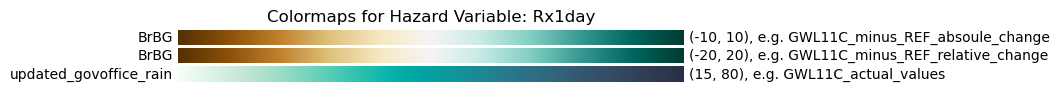

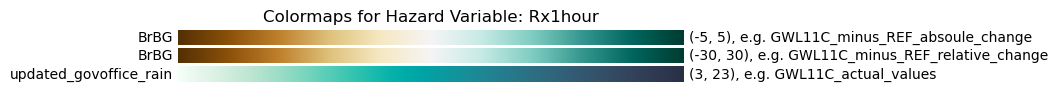

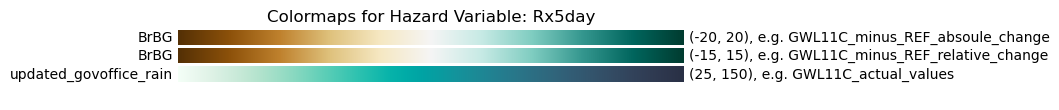

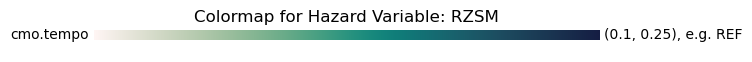

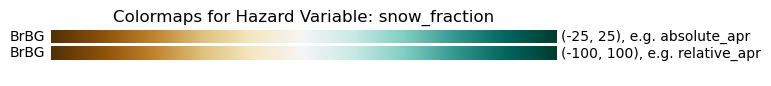

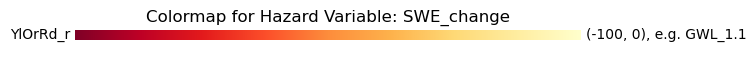

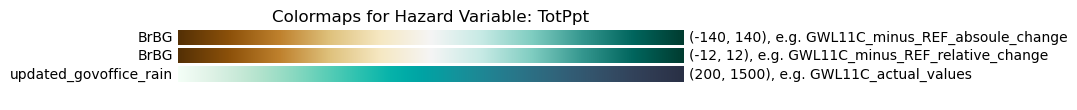

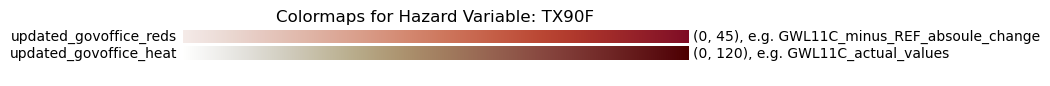

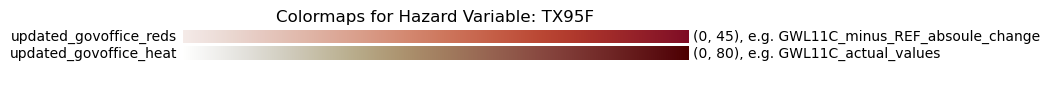

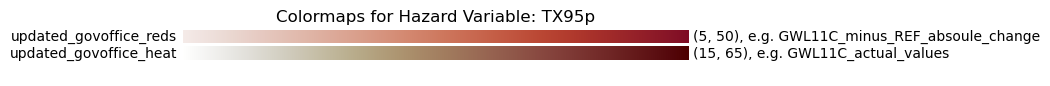

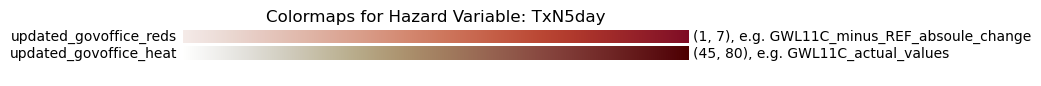

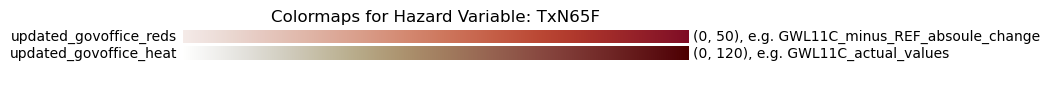

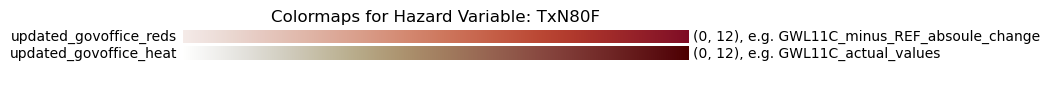

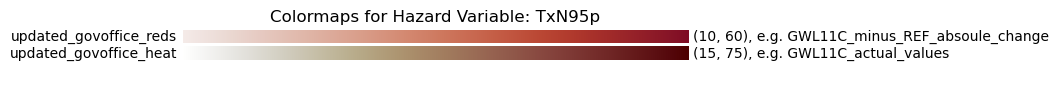

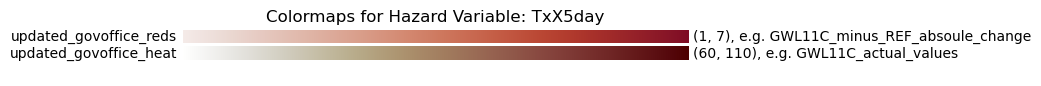

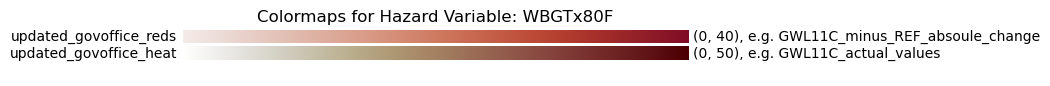

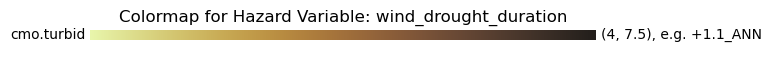

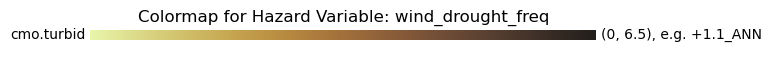

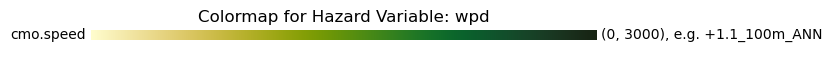

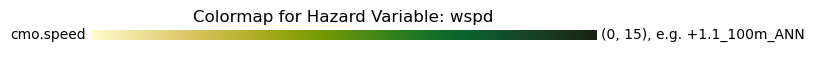

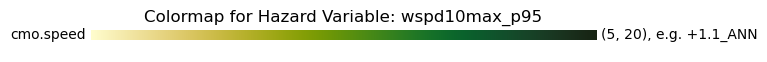

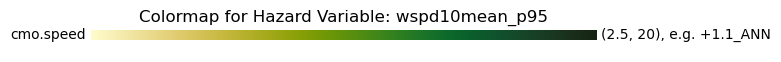

In [5]:
cmap_skip_list = ['seismic']
hazard_skip_list = ['peak']

gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))

for hazard_name in sorted(list(symbology_table['variable_group'].unique()), key=lambda s: s.lower()):
    if hazard_name in hazard_skip_list:
        continue
    rows = symbology_table[symbology_table['variable_group'] == hazard_name]
    nrows = len(rows)
    figh = 0.35 + 0.15 + (nrows + (nrows - 1) * 0.1) * 0.22
    fig, axs = plt.subplots(nrows=nrows + 1, figsize=(6.4, figh))
    fig.subplots_adjust(top=1 - 0.35 / figh, bottom=0.15 / figh, left=0.2, right=0.99)
    axs[0].set_title(f'Colormap{"s" if nrows > 1 else ""} for Hazard Variable: {hazard_name}', fontsize=12)

    for i, (_, row) in enumerate(rows.iterrows()):
        # Get the proper colormap, given replacements/alternatives
        cmap = row['symbology_as_used_by_author_colormap']
        if cmap == '--' or cmap in cmap_skip_list:
            cmap = row['symbology_alternative_colormap']
        elif cmap in color_data['colormaps'] and 'improved_equivalent' in color_data['colormaps'][cmap]:
            cmap = color_data['colormaps'][cmap]['improved_equivalent']
        elif cmap[:-2] in color_data['colormaps'] and 'improved_equivalent' in color_data['colormaps'][cmap[:-2]]:
            cmap = color_data['colormaps'][cmap[:-2]]['improved_equivalent'] + "_r"
        # get vmin/vmax and example subtype
        vmin = (
            row['symbology_alternative_min_value']
            if row['symbology_alternative_min_value'] != '--'
            else row['symbology_as_used_min_value']
        )
        vmax = (
            row['symbology_alternative_max_value']
            if row['symbology_alternative_max_value'] != '--'
            else row['symbology_as_used_max_value']
        )
        ex = json.loads(row['variable_subtype_list'].replace("\'", "\""))[0]
        # plot
        axs[i].imshow(gradient, aspect='auto', cmap=cmap)
        axs[i].text(-0.01, 0.5, cmap, va='center', ha='right', fontsize=10, transform=axs[i].transAxes)
        axs[i].text(1.01, 0.5, f"({vmin}, {vmax}){', e.g. ' if ex else ''}{ex}", va='center', ha='left', fontsize=10, transform=axs[i].transAxes)
    
    # Turn off *all* ticks & spines, not just the ones with colormaps.
    for ax in axs:
        ax.set_axis_off()

    plt.show()
    plt.close(fig)

<a id="cvd-analysis"></a>

## CVD Testing for modified `govoffice` tables

In [6]:
def colormap_evaluation(rda, name, base_variable, variable_subtype, units, cmap, vmin, vmax):
    ##### Sample image in original RGB
    # set up figure
    fig = Figure(figsize=(12,8))
    canvas = FigureCanvas(fig)
    ax = fig.add_subplot(projection=ccrs.epsg(3857))
    cmap = plt.get_cmap(cmap)
    # Get data crs
    crs_data = ccrs.Projection(rda.rio.crs)    
    # Plot pcolormesh with transform
    pcm = ax.pcolormesh(
        rda.x.data, rda.y.data, rda.squeeze().data,
        transform=crs_data, cmap=cmap, vmin=vmin, vmax=vmax
    )
    # Figure decorations
    ax.set_extent([250.7, 258.2, 36.7, 41.2], ccrs.Geodetic())
    ax.add_feature(USCOUNTIES.with_scale('5m'), linewidth=0.5, alpha=0.5)
    ax.add_feature(USSTATES.with_scale('5m'), linewidth=1.0)
    ax.set_title(name, fontsize=14)
    fig.colorbar(pcm, ax=ax, orientation="vertical", shrink=0.7, label=units)
    fig.tight_layout(pad=0)
    ax.margins(0)
    # draw canvas, cache the renderer
    canvas.draw()
    # turn the plot into image array
    renderer = fig.canvas.get_renderer()
    image_array = np.asarray(renderer.buffer_rgba())
    rgb_array = image_array[:, :, :3]
    image_from_plot = rgb_array / 255.

    #### Colorspace conversions
    # Convert to greyscale
    img_greyscale_JCh = cspace_convert(image_from_plot, "sRGB1", "JCh")
    img_greyscale_JCh[..., 1] = 0
    img_greyscale_sRGB = cspace_convert(img_greyscale_JCh, "JCh", "sRGB1")
    # Deuteranomaly
    cvd_space = {
        "name": "sRGB1+CVD",
        "cvd_type": "deuteranomaly",
        "severity": 50
    }
    img_deuteranomaly_sRGB = cspace_convert(image_from_plot, cvd_space, "sRGB1")
    # Deuteranopia
    cvd_space = {
        "name": "sRGB1+CVD",
        "cvd_type": "deuteranomaly",
        "severity": 100
    }
    img_deuteranopia_sRGB = cspace_convert(image_from_plot, cvd_space, "sRGB1")
    # Protanopia
    cvd_space = {
        "name": "sRGB1+CVD",
        "cvd_type": "protanomaly",
        "severity": 100
    }
    img_protanopia_sRGB = cspace_convert(image_from_plot, cvd_space, "sRGB1")
    # Tritanopia
    cvd_space = {
        "name": "sRGB1+CVD",
        "cvd_type": "tritanomaly",
        "severity": 100
    }
    img_tritanopia_sRGB = cspace_convert(image_from_plot, cvd_space, "sRGB1")
    
    #### Overall Figure
    fig, axes = plt.subplot_mosaic(
        [
            ['l', 'l', 'l', 'ab', 'ab', 'ab'],
            ['orig', 'orig', 'd_anom', 'd_anom', 'p_anop', 'p_anop'],
            ['bw', 'bw', 'd_anop', 'd_anop', 't_anop', 't_anop']
        ],
        figsize=(12, 9)
    )
    # Color lightness scale
    x = np.linspace(vmin, vmax, 100)
    color_range_sRGB = cmap(np.linspace(0, 1, len(x)))[:, :3]
    color_range_Lab = cspace_convert(color_range_sRGB, "sRGB1", "CIELab")
    axes['l'].scatter(
        x,
        color_range_Lab[:, 0],
        c = [tuple(row) for row in color_range_sRGB],
        s = 100
    )
    axes['l'].set_ylabel("Lightness (L*)")
    axes['l'].set_ylim([0, 100])
    axes['l'].set_xticks([])
    # ab curves
    axes['ab'].plot(x, color_range_Lab[:, 1], c='tab:red', label='a*')
    axes['ab'].plot(x, color_range_Lab[:, 2], c='tab:blue', label='b*')
    axes['ab'].set_xticks([])
    axes['ab'].set_ylim([-128, 128])
    axes['ab'].yaxis.set_label_position("right")
    axes['ab'].yaxis.tick_right()
    axes['ab'].legend()
    # Sample images
    axes['orig'].imshow(np.clip(image_from_plot,0,1))
    axes['orig'].axis('off')
    axes['orig'].set_title("Full Color")
    axes['bw'].imshow(np.clip(img_greyscale_sRGB,0,1))
    axes['bw'].axis('off')
    axes['bw'].set_title("Greyscale")
    axes['d_anom'].imshow(np.clip(img_deuteranomaly_sRGB,0,1))
    axes['d_anom'].axis('off')
    axes['d_anom'].set_title("Deuteranomaly")
    axes['d_anop'].imshow(np.clip(img_deuteranopia_sRGB,0,1))
    axes['d_anop'].axis('off')
    axes['d_anop'].set_title("Deuteranopia")
    axes['p_anop'].imshow(np.clip(img_protanopia_sRGB,0,1))
    axes['p_anop'].axis('off')
    axes['p_anop'].set_title("Protanopia")
    axes['t_anop'].imshow(np.clip(img_tritanopia_sRGB,0,1))
    axes['t_anop'].axis('off')
    axes['t_anop'].set_title("Tritanopia")
    fig.suptitle(f"Colormap test for '{cmap.name}' - {name}")
    
    return fig

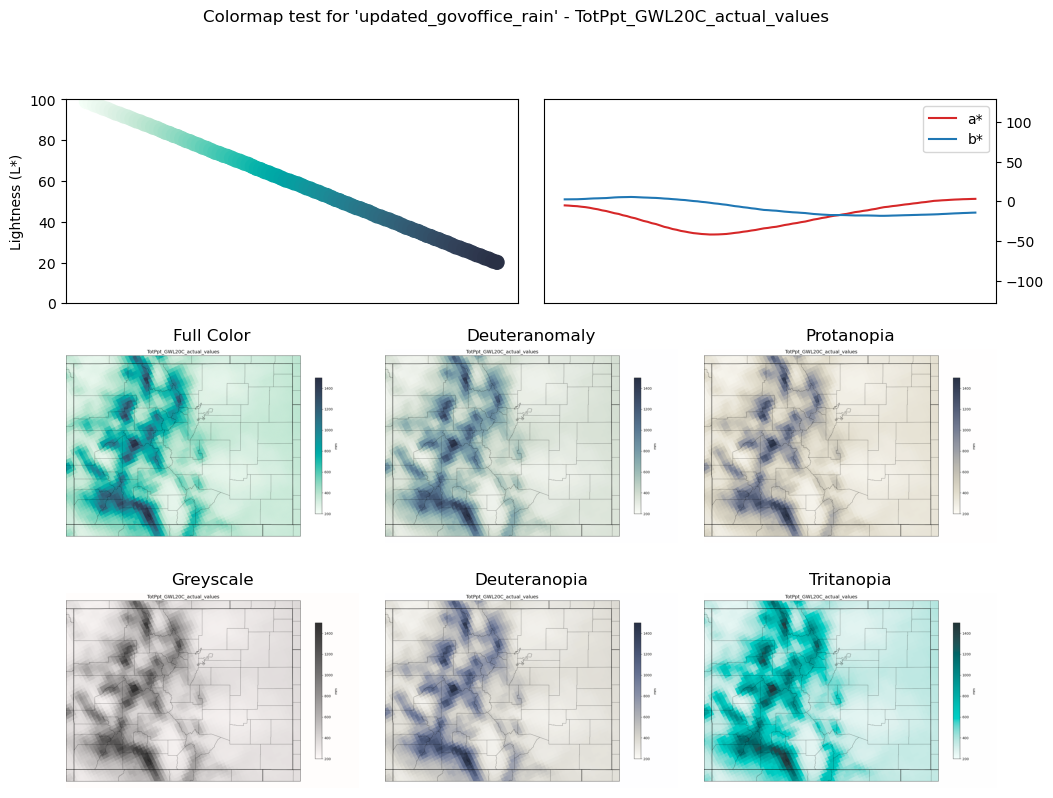

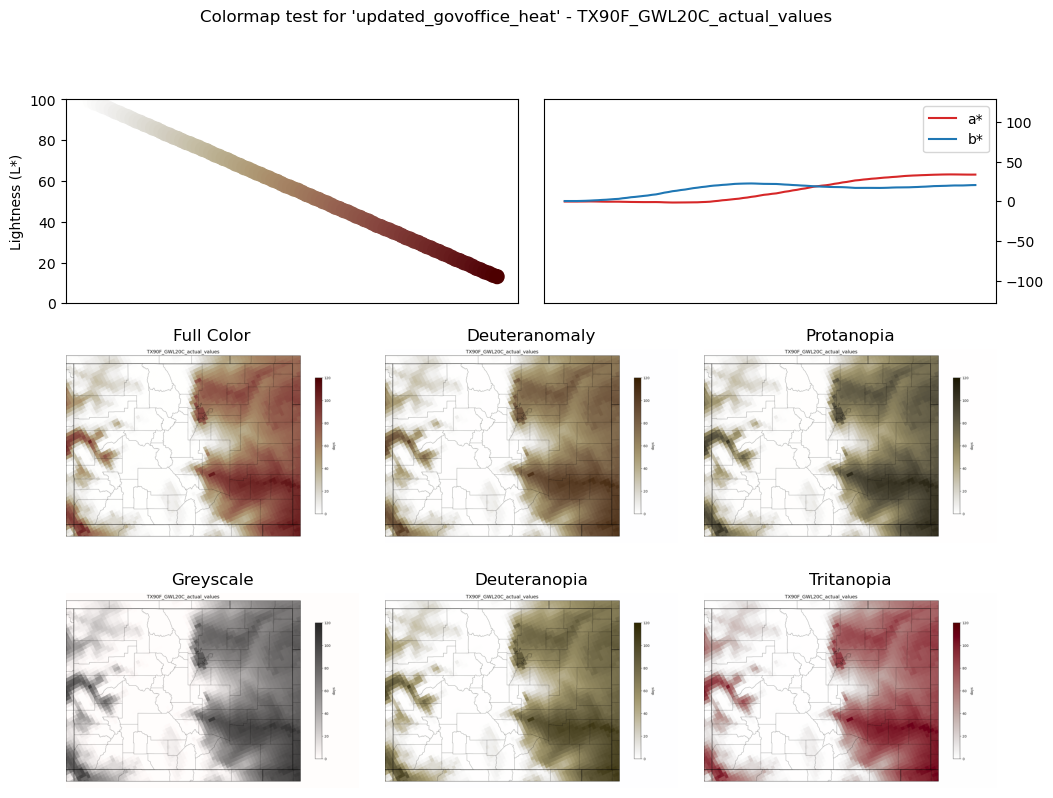

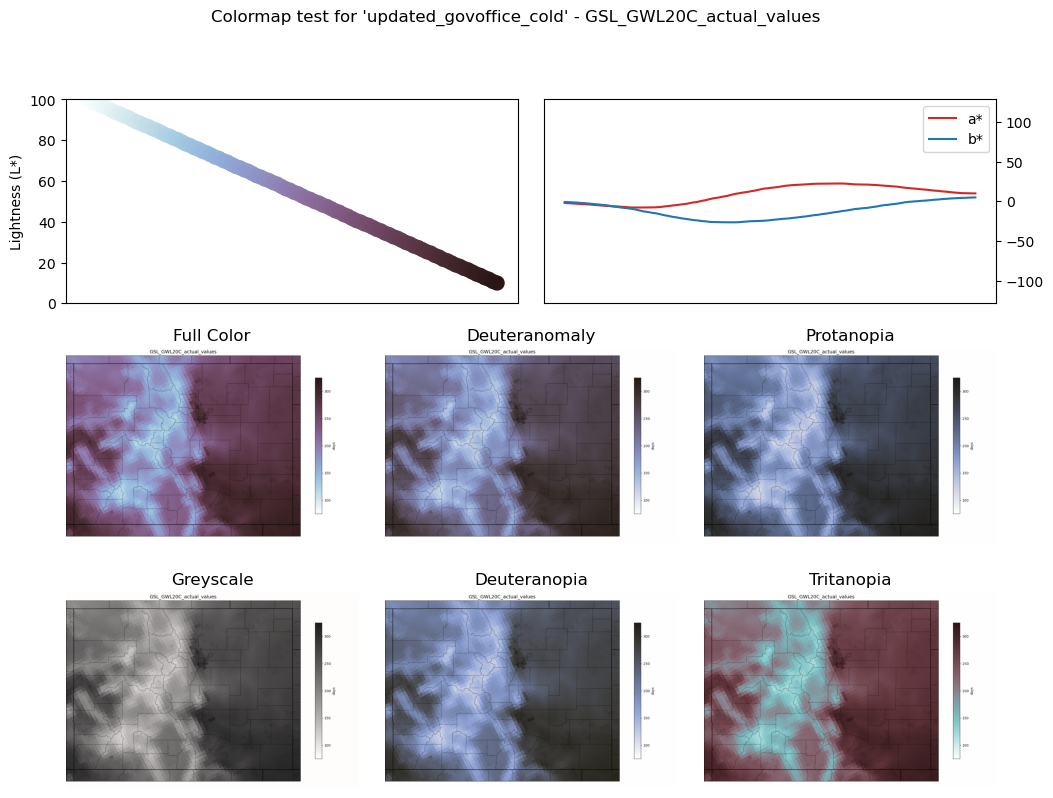

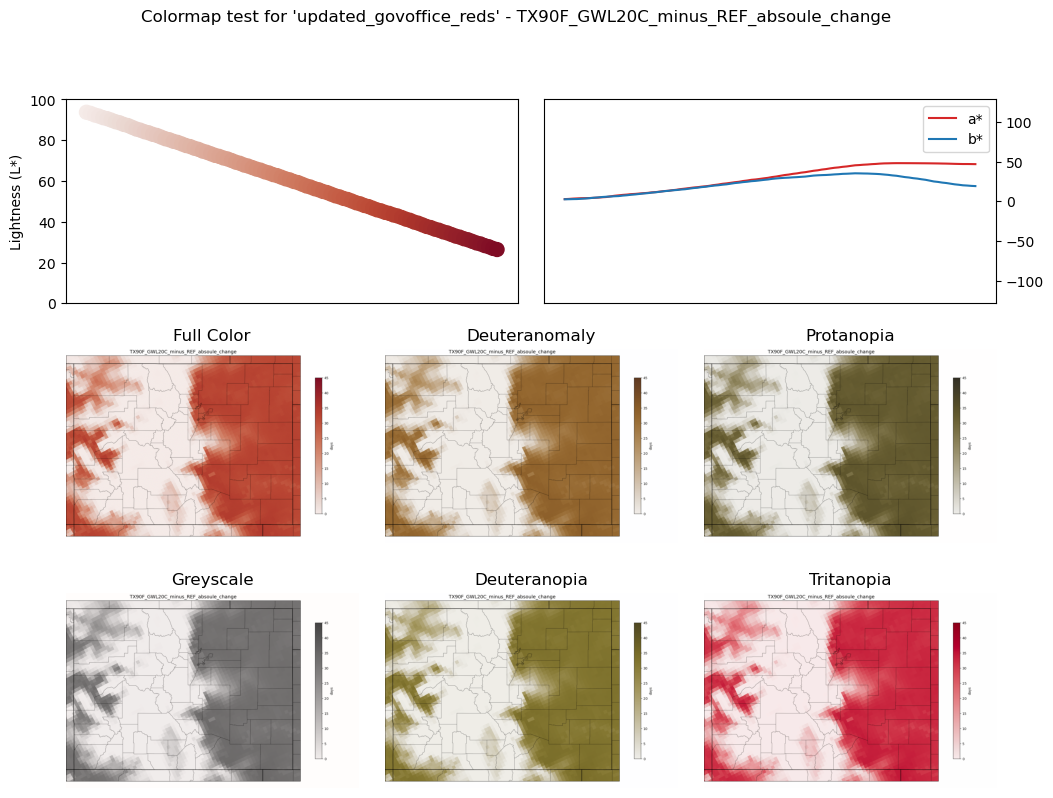

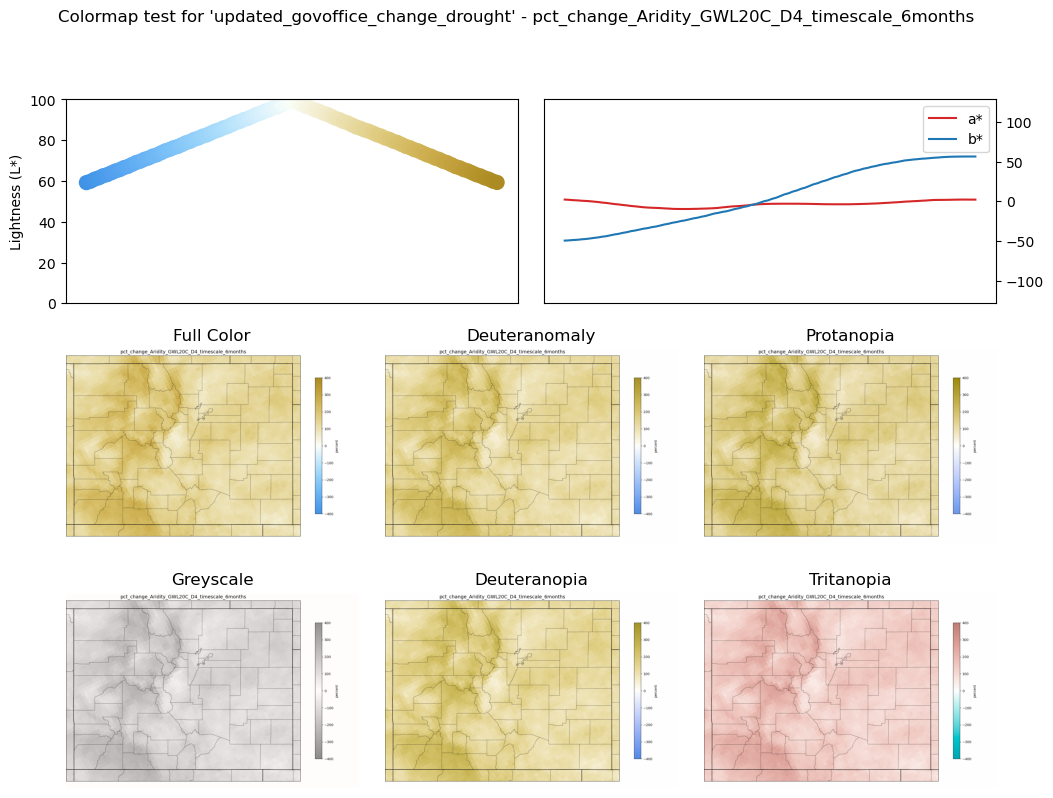

In [7]:
test_keys = [
    ("TotPpt_GWL20C_actual_values", "updated_govoffice_rain"),
    ("TX90F_GWL20C_actual_values", "updated_govoffice_heat"),
    ("GSL_GWL20C_actual_values", "updated_govoffice_cold"),
    ("TX90F_GWL20C_minus_REF_absoule_change", "updated_govoffice_reds"),
    ("pct_change_Aridity_GWL20C_D4_timescale_6months", "updated_govoffice_change_drought")
]
tif_index_url = "https://fs.thielen.science/co_climate/export_20260506/geotiff_index_20260506.csv"
try:
    tif_index = pd.read_csv(tif_index_url)
except Exception as e:
    print(f"Could not access tif index - {e}")
for variable_key, cmap in test_keys:
    row = tif_index[tif_index['variable_key'] == variable_key].iloc[0]
    tif_url = (
        "https://fs.thielen.science/co_climate/export_20260506/"
        + row['geotiff_filepath_lcc']
    )
    of = fsspec.open(tif_url, "rb")
    with of as f:
        rda = rioxarray.open_rasterio(f)
    vmin = float((
        row['symbology_alternative_min_value']
        if row['symbology_alternative_min_value'] != '--'
        else row['symbology_as_used_min_value']
    ))
    vmax = float((
        row['symbology_alternative_max_value']
        if row['symbology_alternative_max_value'] != '--'
        else row['symbology_as_used_max_value']
    ))
    fig = colormap_evaluation(
        rda,
        variable_key,
        row['base_variable'],
        row['variable_subtype'],
        row['units'],
        cmap,
        vmin,
        vmax
    )
    plt.show()
    plt.close(fig)